## 1단계: 필수 라이브러리 설치

In [ ]:
# Streamlit과 ngrok 설치
!pip install streamlit -q # Streamlit 웹 대시보드 라이브러리를 설치
!pip install pyngrok -q # pyngrok 라이브러리설치


## 2단계: 가상 데이터 생성, 모델 학습, pkl 저장

In [14]:
import numpy as np  # 수치 연산 및 배열 처리를 위한 라이브러리
import pandas as pd  # 가상 데이터를 표 형태로 정리하기 위한 라이브러리
import joblib  # 학습된 모델 및 데이터를 파일로 저장/로드
from sklearn.pipeline import Pipeline  # 데이터 전처리와 모델 학습 과정을 하나로 묶어주는 파이프라인
from sklearn.preprocessing import StandardScaler  # 데이터의 특성(Feature) 스케일을 평균 0, 분산 1로 맞추는 표준화 도구
from sklearn.linear_model import LogisticRegression  # 선형 분류 알고리즘인 로지스틱 회귀 모델
from sklearn.neighbors import KNeighborsClassifier  # 주변 이웃 데이터를 기반으로 분류하는 k-NN 모델
from sklearn.svm import SVC  # 결정 경계면과 마진을 이용해 분류하는 서포트 벡터 머신(SVM) 모델
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV  # 데이터 분할, 교차 검증, 하이퍼파라미터 튜닝 도구
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report  # 모델 성능 평가 지표 함수들

# 1. 가상 데이터 생성
np.random.seed(42)  # 실행할 때마다 같은 가상 데이터가 나오도록 고정
sample_count = 300  # 전체 가상 데이터 개수

adult_mortality = np.random.normal(loc=230, scale=80, size=sample_count)  # 성인 사망률 가상 데이터
adult_mortality = np.clip(adult_mortality, 40, 400)  # 세계보건기구에 검색 해보니까 40~50 400~500으로 되어있어서 40 에 400으로 지정했습니다

bmi = np.random.normal(loc=25, scale=5.5, size=sample_count)  # BMI 가상 데이터
bmi = np.clip(bmi, 10, 40) # 이것도 어느정도 극한으로 가능할 정도의 범위로만 했습니다

gdp = np.random.lognormal(mean=np.log(9000), sigma=1.0, size=sample_count)  # GDP 가상 데이터
gdp = np.clip(gdp, 300, 70000)

alcohol = np.random.normal(loc=5.5, scale=3.2, size=sample_count)  # Alcohol 가상 데이터
alcohol = np.clip(alcohol, 0, 30) # 한달에 몇번 먹는지 정도

health_score = ( # 표기할 점수 떄문에 계수를 줄려고 했습니다. 계수를 어떻게 주어야 건강점수가 그나마 정확하게 나올지 몰라서 계수부분은 ai 에게 물어보았습니다
    -0.035 * (adult_mortality - adult_mortality.mean())
    + 0.70 * (bmi - bmi.mean())
    + 0.00005 * (gdp - gdp.mean())
    + 0.25 * (alcohol - alcohol.mean())
    + np.random.normal(0, 5, sample_count) # 평균 0 표준편차 5의 노이즈 추가
)

threshold = np.median(health_score)
life_group = (health_score >= threshold).astype(int) # 건강점수가 기준값 이상이면 1 미만이면 0인 분류 라벨 생성

df = pd.DataFrame({  # 생성한 가상 배열들을 하나의 Pandas DataFrame으로 묶기
    "Adult Mortality": adult_mortality,
    "BMI": bmi,
    "GDP": gdp,
    "Alcohol": alcohol,
    "Life Group": life_group
})

feature_names = ["Adult Mortality", "BMI", "GDP", "Alcohol"] # 리스트로 저장
class_names = {0: "기대수명 낮음", 1: "기대수명 높음"} # 숫자 0과 1을 한글로 바꿈


X = df[feature_names].values  # 배열 형태의 입력 데이터 X로 변환
y = df["Life Group"].values   # 배열 형태의 목표값 y로 변환

# 전체 데이터를 80% 훈련 후보, 20% 테스트 데이터로 분리
X_train_pool, X_test, y_train_pool, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# 과대적합 및 모델 차이를 관찰하기 위해 실제 학습에는 훈련 후보 중 50개만 사용
X_train, _, y_train, _ = train_test_split(X_train_pool,y_train_pool,train_size=50,random_state=42,stratify=y_train_pool)

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),("clf", LogisticRegression(max_iter=1000))]), # 최대 반복 수를 1000번으로
    "k-NN": Pipeline([("scaler", StandardScaler()),("clf", KNeighborsClassifier())]), # 기존 그대로
    "SVM": Pipeline([("scaler", StandardScaler()),("clf", SVC(probability=True))])} #  probability=True인 SVC 분류기를 연결

# GridSearchCV로 탐색할 하이퍼파라미터 후보
param_grids = {# 가장 성능 좋은거 고르는 과정
    "Logistic Regression": {
        "clf__C": [0.1, 1.0, 10.0],# 규제 강도의 후보리스트
        "clf__penalty": ["l2"] # L2 릿지 규제 사용  []안에 저거 L2 소문자임
    },
    "k-NN": {
        "clf__n_neighbors": [3, 5, 7, 9], # 살펴볼 주변 이웃의 개수 후보리스트
        "clf__weights": ["uniform", "distance"]# 가중치 부여 방식 후보리스트
    },
    "SVM": [ # 커널별 불필요한 경고를 방지하기 위해 리스트 내 딕셔너리로 분리 정의
        {
            "clf__C": [0.1, 1.0, 10.0],# 선형 커널용 마진 규제 강도 후보리스트
            "clf__kernel": ["linear"] # 직선이나 평면으로 나눈다는 뜻
        },
        {
            "clf__C": [0.1, 1.0, 10.0], # RBF 커널용 마진 규제 강도 후보리스트
            "clf__kernel": ["rbf"], # 이거는 곡선으로 하겠다는 뜻
            "clf__gamma": ["scale", 0.1, 1.0]  # RBF 커널용 곡률 파라미터 후보리스트, 스케일은 앞에서 적합한거 못찾으면 뭐 알아서 찾아주는 그런거..?
        }
    ]
}

# 4. StratifiedKFold + GridSearchCV 학습 및 평가
best_models = {} # 각 모델명별 최적 모델 객체를 저장할 빈 딕셔너리를 생성
evaluation_summary = { }# 각 모델명별 성능 평가 결과를 저장할 빈 딕셔너리를 생성

for model_name, pipeline in models.items():
    print("\n" + "=" * 100)
    print(f"[{model_name}] 모델 학습 및 튜닝 시작")

    best_cv_score = -1
    best_k_for_model = None  # 가장 높은 점수를 얻은 값을 저장할 변수 초기화
    best_search_obj = None  # 가장 우수한 성능을 낸 객체를 저장할 변수 초기화

    # 3-Fold, 4-Fold, 5-Fold 중 성능이 가장 좋은 교차 검증 구조를 선택
    for k in [3, 4, 5]:  # 3-Fold, 4-Fold, 5-Fold 교차검증을 차례대로 비교
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)  # 클래스 비율을 유지하는 k겹 층화 교차검증 객체를 생성

        grid_search = GridSearchCV(  # 지정한 파이프라인과 하이퍼파라미터 후보로 GridSearchCV 객체를 생성
            estimator=pipeline,  # 탐색 대상 모델 파이프라인을 지정
            param_grid=param_grids[model_name],  # 현재 모델에 맞는 하이퍼파라미터 후보를 지정
            cv=cv,  # 현재 Fold 개수에 해당하는 교차검증 방식을 지정
            scoring="accuracy",  # 모델 선택 기준 점수로 정확도를 사용
        )

        grid_search.fit(X_train, y_train)  # 50개 학습 데이터로 하이퍼파라미터 탐색과 모델 학습을 수행

        if grid_search.best_score_ > best_cv_score:  # 최고 점수가 기존 최고 점수보다 높은지 확인
            best_cv_score = grid_search.best_score_  # 더 좋은 교차검증 정확도를 최고 점수로 갱신
            best_k_for_model = k  # 더 좋은 결과를 낸 Fold 개수를 저장
            best_search_obj = grid_search  # 더 좋은 결과를 낸 GridSearchCV 객체를 저장

    best_estimator = best_search_obj.best_estimator_  # 최종 선택된 GridSearchCV 객체에서 가장 좋은 파이프라인 모델 꺼냄
    best_params = best_search_obj.best_params_  # 최종 선택된 모델의 하이퍼파라미터 값을 꺼냄

    y_pred = best_estimator.predict(X_test)  # 독립 테스트 데이터 X_test에 대해 예측값을 생성

    acc = accuracy_score(y_test, y_pred)  # 테스트 데이터의 정확도 Accuracy를 계산
    prec = precision_score(y_test, y_pred, zero_division=0)  # 테스트 데이터의 정밀도 Precision을 계산
    rec = recall_score(y_test, y_pred, zero_division=0)  # 테스트 데이터의 재현율 Recall을 계산
    f1 = f1_score(y_test, y_pred, zero_division=0)  # 테스트 데이터의 F1-Score를 계산
    cm = confusion_matrix(y_test, y_pred)  # 실제값과 예측값을 비교한 혼동 행렬을 계산

    best_models[model_name] = best_estimator  # 현재 모델의 최적 파이프라인을 best_models 딕셔너리에 저장
    evaluation_summary[model_name] = {  # 현재 모델의 평가 결과를 evaluation_summary 딕셔너리에 저장
        "best_k": best_k_for_model,  # 가장 좋은 결과를 낸 Fold 개수를 저장
        "best_cv_score": best_cv_score,  # 가장 좋은 교차검증 정확도를 저장
        "best_params": best_params,  # 최적 하이퍼파라미터 조합을 저장
        "test_accuracy": acc,  # 테스트 정확도를 저장
        "test_precision": prec,  # 테스트 정밀도를 저장
        "test_recall": rec,  # 테스트 재현율을 저장
        "test_f1_score": f1,  # 테스트 F1-Score를 저장
        "confusion_matrix": cm.tolist()  # NumPy 배열인 혼동 행렬을 저장 가능한 리스트 형태로 변환해 저장
    }

    print(f"선택된 최적 CV 구조: {best_k_for_model}-Fold")  # 선택된 최적 Fold 구조를 출력
    print(f"선택된 최적 하이퍼파라미터: {best_params}")  # 선택된 최적 하이퍼파라미터 값을 출력
    print(f"Test Accuracy : {acc:.4f}")  # 테스트 정확도를 소수점 네 자리까지 출력
    print(f"Test Precision: {prec:.4f}")  # 테스트 정밀도를 위와 같음
    print(f"Test Recall   : {rec:.4f}")  # 테스트 재현율을 위와 같음
    print(f"Test F1-Score : {f1:.4f}")  # 테스트 F1-Score를 위와 같음
    print("Confusion Matrix")  # 혼동 행렬 제목을 출력
    print(cm)  # 혼동 행렬 값을 출력

    print("\nClassification Report")  # 분류 리포트 제목을 출력
    print(classification_report(  # 클래스별 precision, recall, f1-score를 포함한 분류 리포트를 출력
        y_test,  # 실제 정답 라벨을 입력
        y_pred,  # 모델의 예측 라벨을 입력
        target_names=[class_names[0], class_names[1]],  # 0과 1 대신 한글 클래스명을 표시
        zero_division=0  # 분모가 0인 경우 경고 대신 0으로 처리
    ))  # classification_report 출력 명령을 마무리

# 5. 모델 및 메타데이터 저장
payload = {
    "models": best_models,
    "evaluation_summary": evaluation_summary,
    "feature_names": feature_names,
    "class_names": class_names,
    "df": df,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

# 통합 파일 저장
joblib.dump(payload, "life_expectancy_classifier_models.pkl")

# pkl 파일 저장 부분
joblib.dump(best_models["Logistic Regression"], "model_logistic_regression.pkl") #  Logistic Regression  꺼내서  model_logistic_regression.pkl 저장
joblib.dump(best_models["k-NN"], "model_knn.pkl") # 위와 동일
joblib.dump(best_models["SVM"], "model_svm.pkl") # 위와 동일




[Logistic Regression] 모델 학습 및 튜닝 시작
선택된 최적 CV 구조: 4-Fold
선택된 최적 하이퍼파라미터: {'clf__C': 0.1, 'clf__penalty': 'l2'}
Test Accuracy : 0.7167
Test Precision: 0.6970
Test Recall   : 0.7667
Test F1-Score : 0.7302
Confusion Matrix
[[20 10]
 [ 7 23]]

Classification Report
              precision    recall  f1-score   support

     기대수명 낮음       0.74      0.67      0.70        30
     기대수명 높음       0.70      0.77      0.73        30

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60


[k-NN] 모델 학습 및 튜닝 시작
선택된 최적 CV 구조: 4-Fold
선택된 최적 하이퍼파라미터: {'clf__n_neighbors': 5, 'clf__weights': 'distance'}
Test Accuracy : 0.7000
Test Precision: 0.7000
Test Recall   : 0.7000
Test F1-Score : 0.7000
Confusion Matrix
[[21  9]
 [ 9 21]]

Classification Report
              precision    recall  f1-score   support

     기대수명 낮음       0.70      0.70      0.70        30
     기대수명 높음       0.70      0.70      

['model_svm.pkl']

## 3단계: Streamlit 앱 파일 생성

In [ ]:
%%writefile app.py
# 라이브러리 임포트: 웹 UI, 수치 연산, 모델 로드, 데이터 가공을 위한 핵심 패키지들
import streamlit as st  # Streamlit 웹 애플리케이션 제작
import numpy as np  # 입력값 배열 변환
import pandas as pd  # 표 형태 데이터 처리
import joblib  # 저장된 모델 및 메타데이터 로드
import matplotlib.pyplot as plt  # 성능 비교 막대그래프 출력
# 실습 코드를 긁어서 사용하였습니다

st.set_page_config(page_title="기대수명 분류 파이프라인 모델", layout="wide") # 웹 브라우저 페이지 설정

st.title("기대수명 분류 예측 및 웹 대시보드") # 대시보드 제목
st.write("가상 데이터로 학습한 Logistic Regression, k-NN, SVM 모델을 기반으로 성능 비교와 실시간 분류 예측을 수행합니다.") # 대시보드의 목적과 사용된 알고리금 구조에 대한 간략한 설명
st.markdown("---") # 화면을 깔끔하게 분리해 주는 가로 구분선 삽입

def load_classifier_data():
    try: # joblib를 이용해 사전 학습된 모델 객체와 성능 지표가 담긴 딕셔너리 파일을 로드
        return joblib.load("life_expectancy_classifier_models.pkl")
    except FileNotFoundError:
        return None# 실패 시 빈 값 반환

payload = load_classifier_data() # 선언한 함수를 호출하여 변수에 머신러닝 데이터 패키지를

if payload is None:
    st.error("life_expectancy_classifier_models.pkl 파일이 없습니다. 먼저 코랩에서 모델 학습 셀을 실행하세요.")
    st.stop() #Streamlit 실행중단

models = payload["models"] # payload에서 학습된 최적 모델 3종 딕셔너리를 꺼냄
evaluation_summary = payload["evaluation_summary"]  # payload에서 모델별 성능 평가 결과 딕셔너리를 꺼냄
feature_names = payload["feature_names"]  # payload에서 모델 입력 특성 이름 리스트를 꺼냄
class_names = payload["class_names"]  # payload에서 숫자 라벨과 한글 클래스명 매핑 정보를 꺼냄

# 2. 성능 비교 표 출력
st.subheader("독립된 검증 데이터(Test Data) 기반 종합 성능 비교")

summary_data = []  # 빈 리스트
for model_name, info in evaluation_summary.items():  # 딕셔너리에서 모델명과 정보 딕셔너리를 하나씩 꺼냄
    summary_data.append({  # 현재 모델의 성능 정보를 하나의 행으로 만들어 리스트에 추가
        "모델명": model_name,
        "최적 CV 구조": f"{info['best_k']}-Fold",
        "CV Accuracy": f"{info['best_cv_score']:.2%}",
        "Test Accuracy (정확도)": f"{info['test_accuracy']:.2%}",
        "Test Precision (정밀도)": f"{info['test_precision']:.2%}",
        "Test Recall (재현율)": f"{info['test_recall']:.2%}",
        "Test F1-Score": f"{info['test_f1_score']:.4f}"
    })
df_summary = pd.DataFrame(summary_data)  # 리스트 형태의 성능 데이터를 Pandas DataFrame으로 변환
st.dataframe(df_summary, use_container_width=True, hide_index=True) # 성능표를 Streamlit의 인터렉치브 표 형태로 화면에 출력


# 3. Test Accuracy 막대그래프
st.subheader("📈 모델별 Test Accuracy 비교")

graph_df = pd.DataFrame({  # 막대그래프에 사용할 모델명과 테스트 정확도 데이터를 DataFrame 생성
    "Model": list(evaluation_summary.keys()),
    "Test Accuracy": [evaluation_summary[name]["test_accuracy"] for name in evaluation_summary.keys()]
})

fig, ax = plt.subplots(figsize=(8, 4)) # 그래프 크기를 8x4로 설정하여 Figure와 Axes 객체를 생성
ax.bar(graph_df["Model"], graph_df["Test Accuracy"])
ax.set_ylim(0, 1)
ax.set_ylabel("Test Accuracy")
ax.set_xlabel("Model")
ax.set_title("Model Test Accuracy Comparison")
st.pyplot(fig)
st.markdown("---")

# 4. 사이드바 입력 UI
st.sidebar.header("새로운 데이터 입력")    # 왼쪽 사이드바 영역에 입력용 헤더 텍스트 출력
adult_mortality = st.sidebar.slider("Adult Mortality",min_value=40.0,max_value=400.0,value=220.0,step=1.0)   # 사용자가 조정할 수 있는 그 슬라이더 생성
bmi = st.sidebar.slider("BMI",min_value=10.0,max_value=40.0,value=25.0,step=0.1) # 사용자가 조정할 수 있는 그 슬라이더 생성
gdp = st.sidebar.slider("GDP",min_value=300.0,max_value=70000.0,value=9000.0,step=100.0) # 사용자가 조정할 수 있는 그 슬라이더 생성
alcohol = st.sidebar.slider("Alcohol",min_value=0.0,max_value=30.0,value=5.5,step=0.1) # 사용자가 조정할 수 있는 그 슬라이더 생성
selected_model_name = st.sidebar.selectbox("실시간 예측에 사용할 모델 선택",list(models.keys()))
input_data = np.array([[adult_mortality, bmi, gdp, alcohol]], dtype=float)

# 5. 선택 모델의 실시간 예측 결과
st.subheader(
    f" 실시간 예측 판정 "
    f"[Adult Mortality: {adult_mortality:.1f}, BMI: {bmi:.1f}, GDP: {gdp:.0f}, Alcohol: {alcohol:.1f}]"
)

selected_model = models[selected_model_name]  # 선택한 모델 이름에 해당하는 학습된 파이프라인 객체 가져오기
selected_pred = int(selected_model.predict(input_data)[0])  # 선택한모델로 입력값을 예측하고 결과 라벨을 정수로 변환
selected_class_name = class_names[selected_pred]  # 예측된 숫자 라벨을 한글 클래스명으로 변환

if hasattr(selected_model.named_steps["clf"], "predict_proba"):  # 선택한 모델의 분류기가 확률 예측 기능을 제공하는지 확인
    selected_proba = selected_model.predict_proba(input_data)[0]  # 선택한 모델로 각 클래스에 대한 예측 확률을 계산
    confidence = selected_proba[selected_pred]
    st.metric(
        label=f"선택 모델: {selected_model_name}",
        value=selected_class_name,
        delta=f"예측 확률 {confidence:.1%}"
    )
else:
    st.metric(
        label=f"선택 모델: {selected_model_name}",
        value=selected_class_name
    )

st.info("왼쪽 사이드바에서 4개 변수 값을 조절하면 선택한 모델의 예측 결과가 즉시 바뀝니다.")


# 6. 모델 3종 예측 결과 카드
st.markdown("### 모델별 상세 예측 결과")

cols = st.columns(3) # 컬럼 4개 만들기

for idx, (model_name, pipeline) in enumerate(models.items()):  # 모델 딕셔너리에서 인덱스, 모델명, 파이프라인을 하나씩 꺼내 반복
    y_pred = int(pipeline.predict(input_data)[0]) # 입력값을 예측하고 결과라벨을 정수로 변환
    pred_class = class_names[y_pred]  #예측 라벨을 한글 클래스명으로 변화 ㄴ
    if hasattr(pipeline.named_steps["clf"], "predict_proba"):
        proba = pipeline.predict_proba(input_data)[0]
        proba_text = f"예측 확률 {proba[y_pred]:.1%}"
    else:
        proba_text = "확률 제공 불가"

    with cols[idx]:  # 현재 모델 결과를 idx번째 컬럼 안에 출력
        st.info(f"### {model_name}")  # 현재 컬럼 상단에 모델명을 정보 박스로 출력
        st.metric(label="판정 결과", value=pred_class, delta=proba_text)  # 현재 모델의 판정 결과와 예측 확률을 metric 형태로 출력

        cm = evaluation_summary[model_name]["confusion_matrix"]  # 현재 모델의 혼동 행렬 데이터를 평가 결과 딕셔너리에서 꺼냄
        cm_df = pd.DataFrame(cm,  index=[f"실제 {class_names[0]}", f"실제 {class_names[1]}"],  # 행 이름에 실제 클래스명을 표시
            columns=[f"예측 {class_names[0]}", f"예측 {class_names[1]}"]  # 열 이름에 예측 클래스명을 표시
        )

        st.markdown("**혼동 행렬 (Confusion Matrix)**")  # 혼동 행렬 표 위에 제목을 출력
        st.table(cm_df)  # 혼동 행렬을 고정된 표 형태로 출력

        st.caption(f"선택된 최적 하이퍼파라미터: {evaluation_summary[model_name]['best_params']}")  # 현재 모델의 최적 하이퍼파라미터를 작은 설명 문구로 출력
        classifier = pipeline.named_steps["clf"]  # 파이프라인 내부에서 실제 분류기 객체만 꺼냄
        if model_name == "Logistic Regression":  # 현재 모델이 Logistic Regression인지 확인
            st.markdown("---")  # 모델 정보 영역을 구분하기 위해 가로선을 출력
            st.markdown("**로지스틱 회귀 파라미터**")  # 로지스틱 회귀 계수 영역 제목을 출력
            coef_df = pd.DataFrame({  # 로지스틱 회귀 계수를 표로 만들기 위해 DataFrame을 생성
                "Feature": feature_names,
                "Coefficient": classifier.coef_[0]
            })
            st.dataframe(coef_df, hide_index=True, use_container_width=True)  # 로지스틱 회귀 계수 표를 화면에 출력
            st.write(f"절편 b: `{classifier.intercept_[0]:.4f}`")  # 로지스틱 회귀의 절편 값을 소수점 네 자리로 출력

        elif model_name == "SVM":
            st.markdown("---")
            st.markdown("**SVM 결정 경계 정보**")
            if hasattr(classifier, "coef_"):  # SVM이 선형 커널이라 coef_ 속성을 가지고 있는지 확
                coef_df = pd.DataFrame({  # 선형 SVM의 계수를 표로 만들기 위해 DataFrame을 생성
                    "Feature": feature_names,  # Feature 컬럼에는 입력 특성 이름
                    "Coefficient": classifier.coef_[0]  # Coefficient 컬럼에는 SVM이 학습한 선형 계수
                })
                st.dataframe(coef_df, hide_index=True, use_container_width=True)  # SVM 계수 표를 화면에 출력
                st.write(f"절편 b: `{classifier.intercept_[0]:.4f}`")  # 선형 SVM의 절편 값을 소수점 네 자리로 출력
            else:
                st.caption("RBF 커널이 선택된 경우 선형 계수는 직접 표시되지 않습니다.")  # 비선형 커널에서는 선형 계수를 직접 표시할 수 없다는 설명을 출력

        elif model_name == "k-NN":  # 현재 모델이 k-NN인지 확인
            st.markdown("---")  # 모델 정보 영역을 구분하기 위해 가로선을 출력
            st.markdown("**k-NN 모델 정보**")  # k-NN 모델 정보 영역 제목을 출력
            st.write(f"이웃 개수 n_neighbors: `{classifier.n_neighbors}`")  # k-NN이 사용하는 이웃 개수를 출력
            st.write(f"가중치 방식 weights: `{classifier.weights}`")  # k-NN이 사용하는 이웃 가중치 방식을 출력

Overwriting app.py


## 4단계: ngrok을 이용한 웹 배포

실행하면 ngrok authtoken 입력창이 나옵니다. 본인 토큰을 입력하면 Public URL이 출력됩니다.

In [ ]:
# 기존 Streamlit/ngrok 프로세스 정리 후 다시 실행
!pip install streamlit pyngrok -q

from pyngrok import ngrok
import os
import time
import getpass

# 기존 ngrok 터널 종료
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3DymICmdFjvI4NnonCNSbhyKb81_ongtfTGKe1j1TAeGE94n")

# Streamlit 앱 실행
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /content/streamlit.log 2>&1 &")

# 서버 부팅 대기
time.sleep(3)

# 8501 포트 외부 공개
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print("Streamlit 웹 서비스가 배포되었습니다.")
print(f"Public URL: {public_url}")
print("=" * 60)


Streamlit 웹 서비스가 배포되었습니다.
Public URL: NgrokTunnel: "https://cage-gambling-county.ngrok-free.dev" -> "http://localhost:8501"


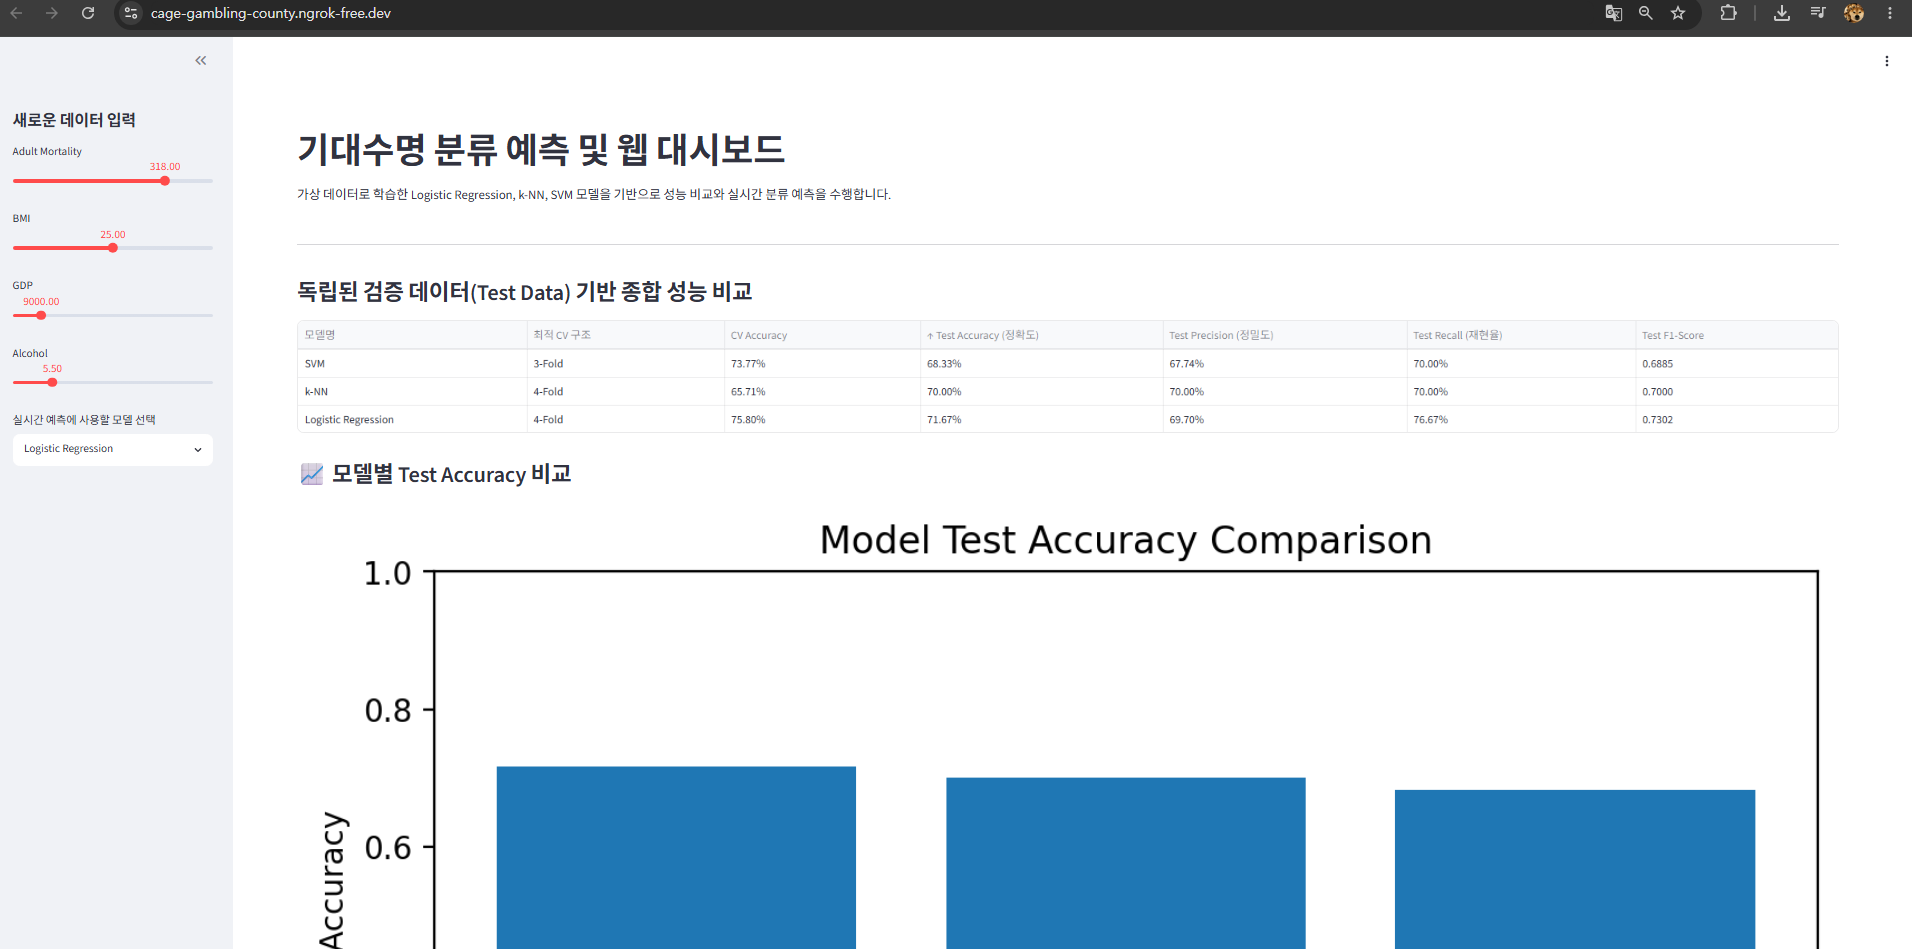

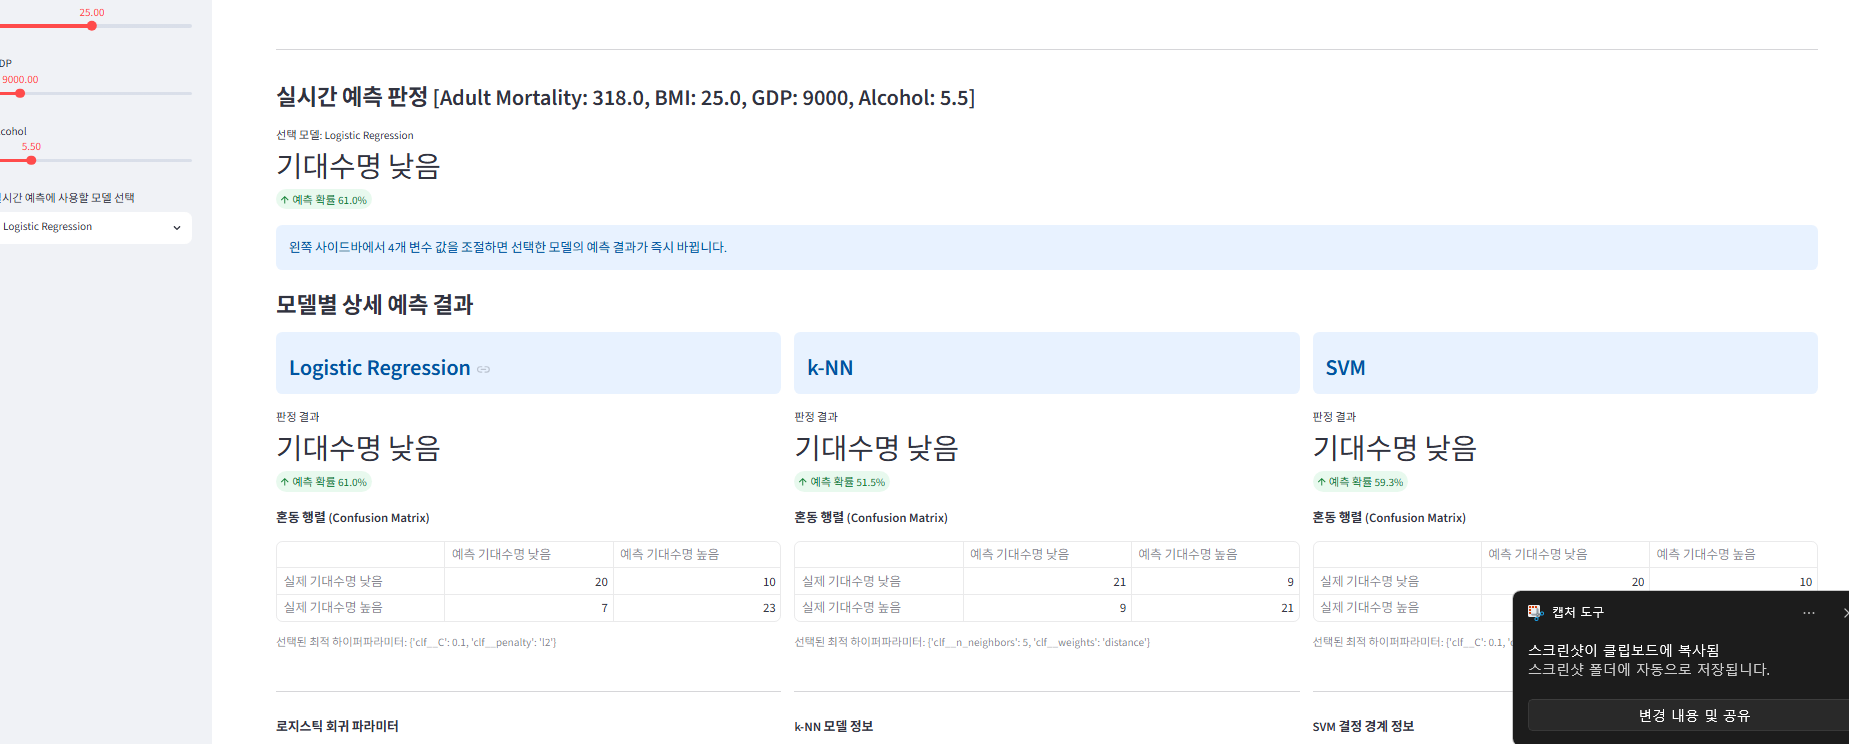